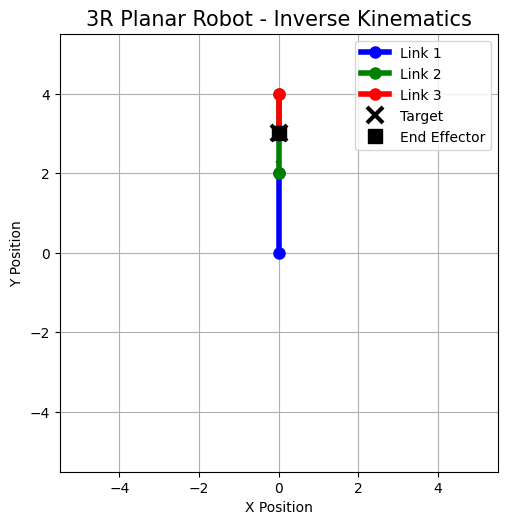

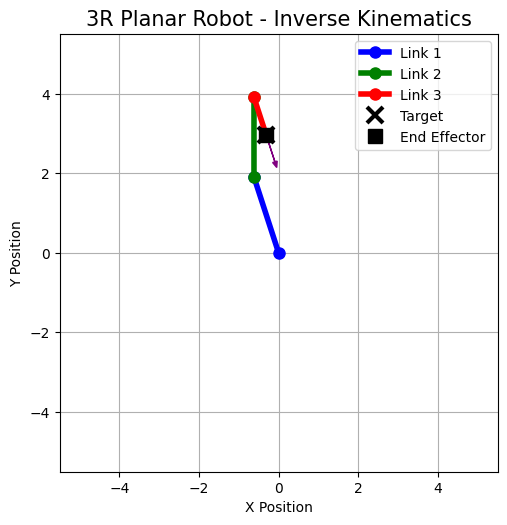

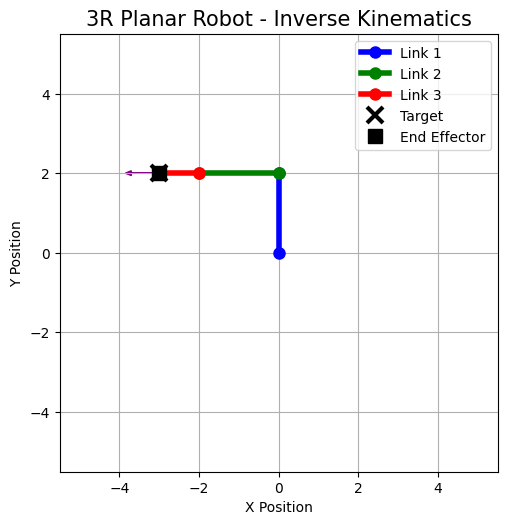

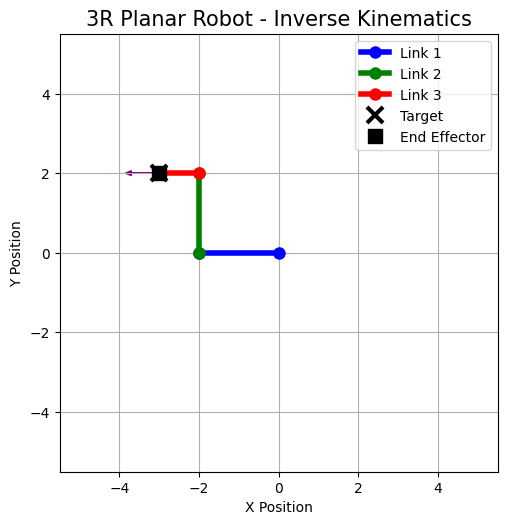

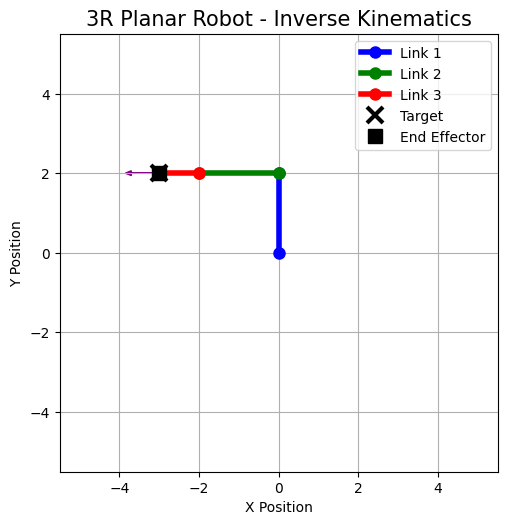

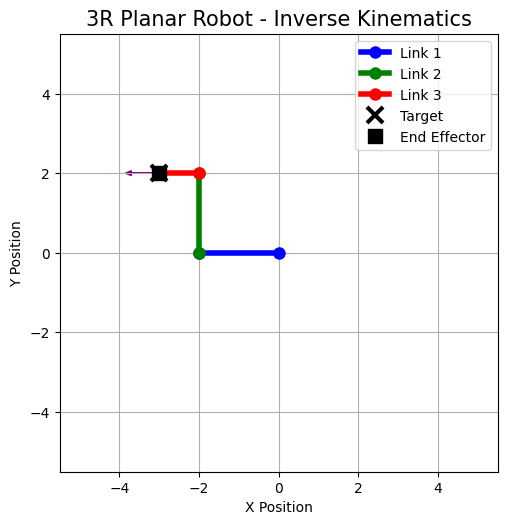

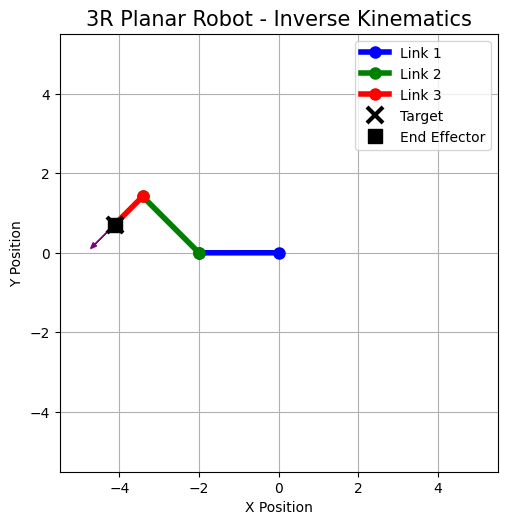

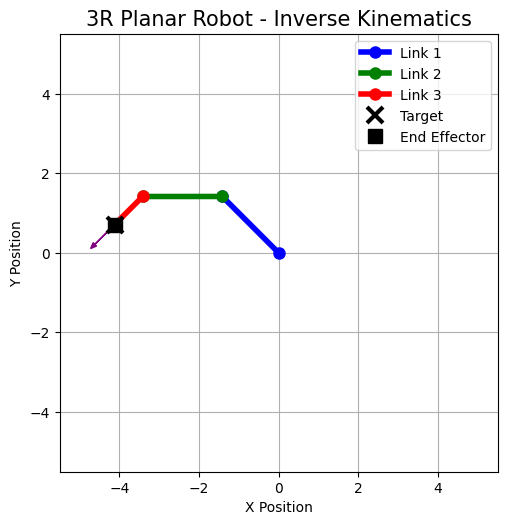

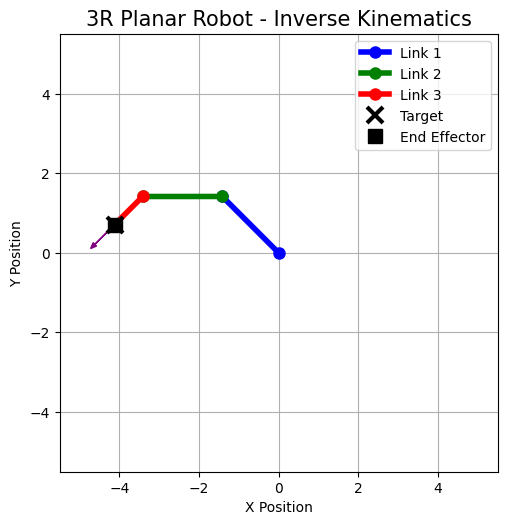

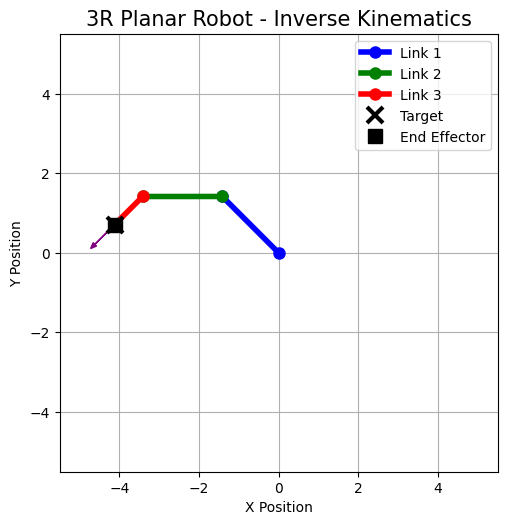

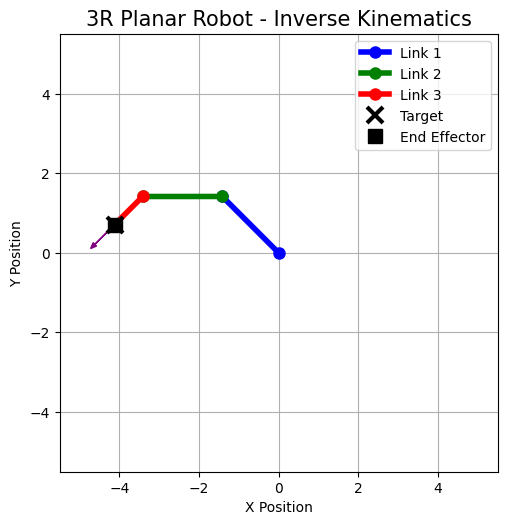

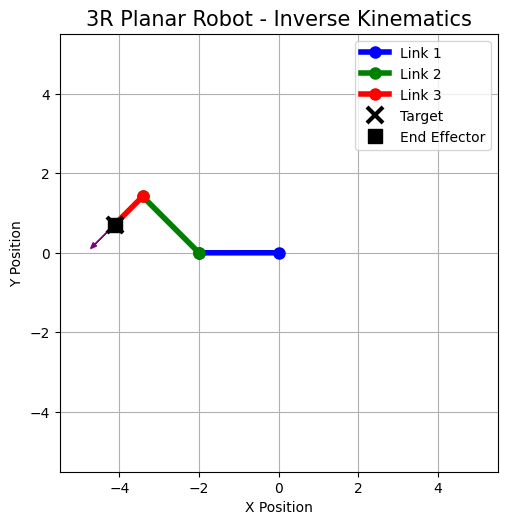

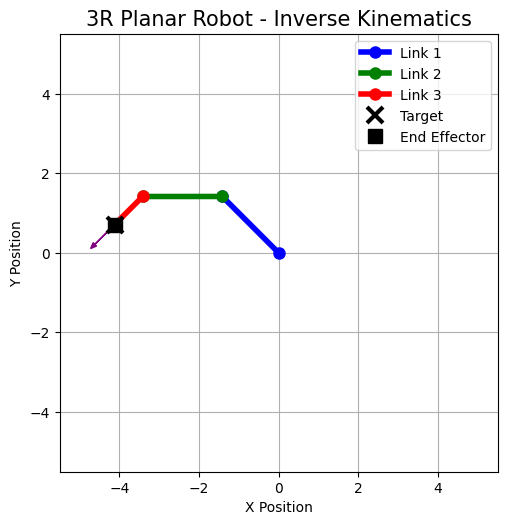

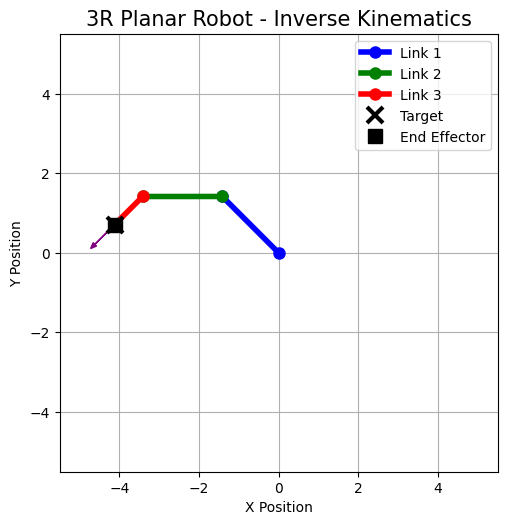

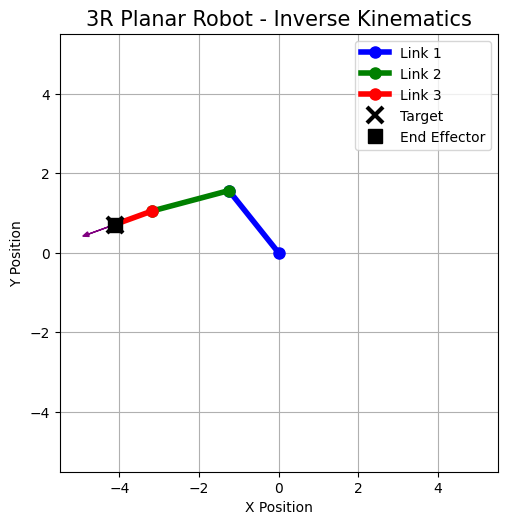

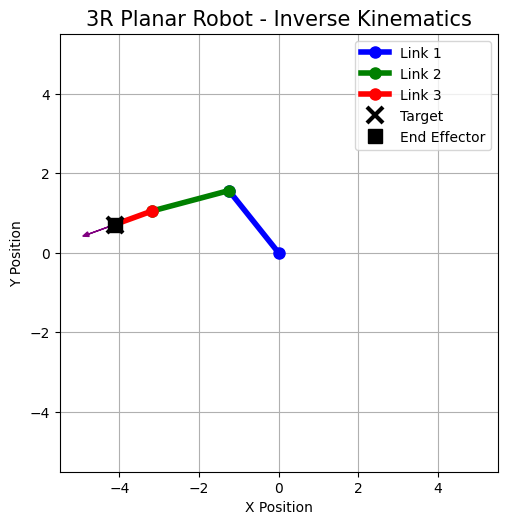

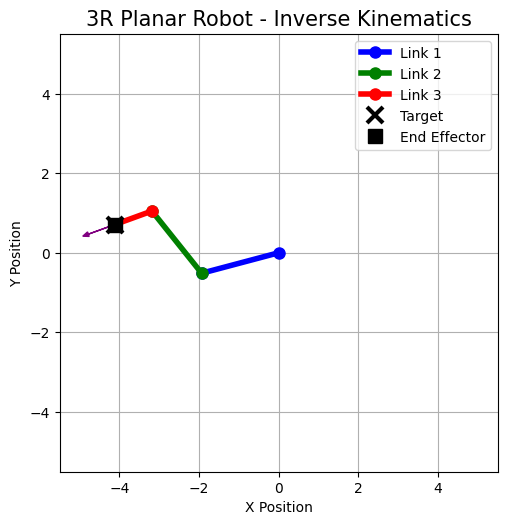

In [4]:
import numpy as np
import tkinter as tk
from tkinter import ttk
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg


# =====================================================
# INVERSE KINEMATICS FUNCTION
# =====================================================
def inverse_kinematics(x, y, phi_deg, l1, l2, l3):

    phi = np.radians(phi_deg)

    X = x - l3 * np.cos(phi)
    Y = y - l3 * np.sin(phi)

    D = (X**2 + Y**2 - l1**2 - l2**2) / (2 * l1 * l2)

    if abs(D) > 1:
        return None

    solutions = []

    theta2_down = np.arccos(D)
    theta2_up = -np.arccos(D)

    for theta2 in [theta2_down, theta2_up]:

        k1 = l1 + l2 * np.cos(theta2)
        k2 = l2 * np.sin(theta2)

        theta1 = np.arctan2(Y, X) - np.arctan2(k2, k1)

        theta3 = phi - theta1 - theta2

        solutions.append((theta1, theta2, theta3))

    return solutions


# =====================================================
# COMPUTE BUTTON
# =====================================================
def compute():

    for widget in plot_frame.winfo_children():
        widget.destroy()

    try:
        l1 = float(entry_l1.get())
        l2 = float(entry_l2.get())
        l3 = float(entry_l3.get())

        x = float(entry_x.get())
        y = float(entry_y.get())
        phi_deg = float(entry_phi.get())

    except ValueError:
        result_label.config(text="Invalid Input!")
        return

    solutions = inverse_kinematics(
        x, y, phi_deg,
        l1, l2, l3
    )

    if solutions is None:
        result_label.config(
            text="Target Outside Workspace!"
        )
        return

    index = solution_var.get()

    theta1, theta2, theta3 = solutions[index]

    result_label.config(
        text=f"θ1 = {np.degrees(theta1):.2f}°\n"
             f"θ2 = {np.degrees(theta2):.2f}°\n"
             f"θ3 = {np.degrees(theta3):.2f}°"
    )

    # =================================================
    # FORWARD KINEMATICS FOR PLOTTING
    # =================================================

    x0, y0 = 0, 0

    x1 = l1 * np.cos(theta1)
    y1 = l1 * np.sin(theta1)

    x2 = x1 + l2 * np.cos(theta1 + theta2)
    y2 = y1 + l2 * np.sin(theta1 + theta2)

    x3 = x2 + l3 * np.cos(theta1 + theta2 + theta3)
    y3 = y2 + l3 * np.sin(theta1 + theta2 + theta3)

    # =================================================
    # PLOT
    # =================================================

    fig, ax = plt.subplots(figsize=(7, 7))

    # Link 1
    ax.plot(
        [x0, x1],
        [y0, y1],
        'bo-',
        linewidth=4,
        markersize=8,
        label='Link 1'
    )

    # Link 2
    ax.plot(
        [x1, x2],
        [y1, y2],
        'go-',
        linewidth=4,
        markersize=8,
        label='Link 2'
    )

    # Link 3
    ax.plot(
        [x2, x3],
        [y2, y3],
        'ro-',
        linewidth=4,
        markersize=8,
        label='Link 3'
    )

    # Target Point
    ax.plot(
        x, y,
        'kx',
        markersize=12,
        markeredgewidth=3,
        label='Target'
    )

    # End Effector
    ax.plot(
        x3, y3,
        'ks',
        markersize=10,
        label='End Effector'
    )

    # Orientation Arrow
    phi = np.radians(phi_deg)

    ax.arrow(
        x3,
        y3,
        0.7 * np.cos(phi),
        0.7 * np.sin(phi),
        head_width=0.12,
        head_length=0.15,
        fc='purple',
        ec='purple'
    )

    ax.set_title(
        "3R Planar Robot - Inverse Kinematics",
        fontsize=15
    )

    ax.set_xlabel("X Position")
    ax.set_ylabel("Y Position")

    ax.grid(True)

    ax.set_aspect('equal', adjustable='box')

    reach = l1 + l2 + l3

    ax.set_xlim(-reach - 0.5, reach + 0.5)
    ax.set_ylim(-reach - 0.5, reach + 0.5)

    ax.legend()

    canvas = FigureCanvasTkAgg(
        fig,
        master=plot_frame
    )

    canvas.draw()

    canvas.get_tk_widget().pack(
        fill=tk.BOTH,
        expand=True
    )


# =====================================================
# GUI WINDOW
# =====================================================

root = tk.Tk()
root.title("3R Planar Robot - Inverse Kinematics")
root.geometry("1200x700")


# =====================================================
# LEFT PANEL
# =====================================================

input_frame = ttk.Frame(root, padding=10)
input_frame.pack(
    side=tk.LEFT,
    fill=tk.Y
)

title = ttk.Label(
    input_frame,
    text="Inverse Kinematics",
    font=("Arial", 14, "bold")
)
title.pack(pady=10)


# Link Lengths
ttk.Label(input_frame, text="L1").pack()
entry_l1 = ttk.Entry(input_frame, width=15)
entry_l1.insert(0, "2")
entry_l1.pack()

ttk.Label(input_frame, text="L2").pack()
entry_l2 = ttk.Entry(input_frame, width=15)
entry_l2.insert(0, "2")
entry_l2.pack()

ttk.Label(input_frame, text="L3").pack()
entry_l3 = ttk.Entry(input_frame, width=15)
entry_l3.insert(0, "1")
entry_l3.pack()

ttk.Separator(input_frame).pack(
    fill='x',
    pady=10
)

# Desired Pose
ttk.Label(input_frame,
          text="X").pack()

entry_x = ttk.Entry(
    input_frame,
    width=15
)
entry_x.insert(0, "3")
entry_x.pack()

ttk.Label(input_frame,
          text="Y").pack()

entry_y = ttk.Entry(
    input_frame,
    width=15
)
entry_y.insert(0, "2")
entry_y.pack()

ttk.Label(input_frame,
          text="Phi (deg)").pack()

entry_phi = ttk.Entry(
    input_frame,
    width=15
)
entry_phi.insert(0, "45")
entry_phi.pack()

ttk.Separator(input_frame).pack(
    fill='x',
    pady=10
)

# Solution Selection
solution_var = tk.IntVar(value=0)

ttk.Label(
    input_frame,
    text="Choose Solution"
).pack()

ttk.Radiobutton(
    input_frame,
    text="Elbow Down",
    variable=solution_var,
    value=0
).pack()

ttk.Radiobutton(
    input_frame,
    text="Elbow Up",
    variable=solution_var,
    value=1
).pack()

ttk.Button(
    input_frame,
    text="Compute IK",
    command=compute
).pack(pady=15)

result_label = ttk.Label(
    input_frame,
    text="Joint Angles",
    font=("Arial", 11, "bold")
)

result_label.pack(pady=10)


# =====================================================
# RIGHT PANEL
# =====================================================

plot_frame = ttk.Frame(root)
plot_frame.pack(
    side=tk.RIGHT,
    fill=tk.BOTH,
    expand=True
)

root.mainloop()